In [1]:
import pandas as pd
df = pd.read_csv('cleaned_data.csv')
print(df.shape)
print(df.isnull().sum().sum())
print(df.dtypes)

(15002, 17)
0
customer_id            object
age                   float64
gender                 object
city                   object
tenure_months         float64
contract_type          object
monthly_charges       float64
total_spend           float64
num_products            int64
login_frequency       float64
last_login_days       float64
support_tickets         int64
payment_method         object
device                 object
satisfaction_score    float64
referral_source        object
churn                   int64
dtype: object


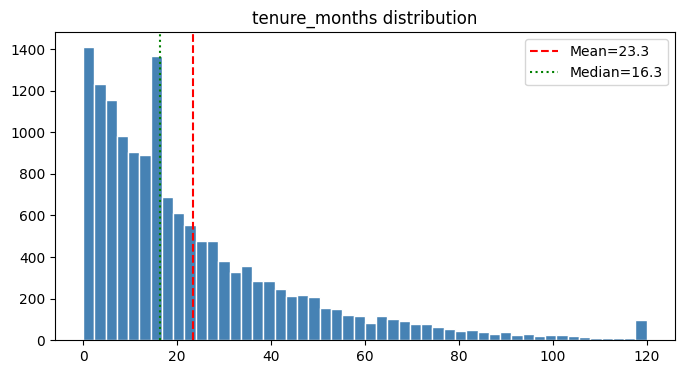

Mean: 23.33
Median: 16.34
Skewness: 1.714


In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df['tenure_months'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(df['tenure_months'].mean(), color='red', linestyle='--', label=f'Mean={df["tenure_months"].mean():.1f}')
plt.axvline(df['tenure_months'].median(), color='green', linestyle=':', label=f'Median={df["tenure_months"].median():.1f}')
plt.legend()
plt.title('tenure_months distribution')
plt.show()

print("Mean:", df['tenure_months'].mean().round(2))
print("Median:", df['tenure_months'].median().round(2))
print("Skewness:", df['tenure_months'].skew().round(3))

In [3]:
num_cols = ['age', 'tenure_months', 'total_spend', 'monthly_charges', 'login_frequency', 'last_login_days','satisfaction_score']
for col in num_cols:
    print(f"{col} -> skew: {df[col].skew().round(3)}")

age -> skew: 0.338
tenure_months -> skew: 1.714
total_spend -> skew: 3.223
monthly_charges -> skew: 9.485
login_frequency -> skew: 0.373
last_login_days -> skew: 2.002
satisfaction_score -> skew: -0.647


In [4]:
import numpy as np
df['monthly_charges_log'] = np.log1p(df['monthly_charges'])
print(df['monthly_charges_log'].skew().round(3))

0.527


In [5]:
print(df['churn'].value_counts())
print(df['churn'].mean().round(3))

churn
0    8542
1    6460
Name: count, dtype: int64
0.431


In [6]:
# Churn rate by tenure bucket
df['tenure_bucket'] = pd.cut(df['tenure_months'], 
                              bins=[0,6,12,24,48,200],
                              labels=['<6m','6-12m','1-2yr','2-4yr','4yr+'])
print(df.groupby('tenure_bucket')['churn'].mean().round(3))

tenure_bucket
<6m      0.643
6-12m    0.566
1-2yr    0.461
2-4yr    0.291
4yr+     0.076
Name: churn, dtype: float64


C:\Users\reddy\AppData\Local\Temp\ipykernel_14948\1715274086.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('tenure_bucket')['churn'].mean().round(3))


In [7]:
print(df.groupby('satisfaction_score')['churn'].mean().round(3))

satisfaction_score
1.0    0.420
2.0    0.425
3.0    0.427
4.0    0.431
5.0    0.440
Name: churn, dtype: float64


In [8]:
print(df['satisfaction_score'].median())

4.0


In [9]:
print(df['satisfaction_score'].value_counts().sort_index())

satisfaction_score
1.0    1206
2.0    1804
3.0    3016
4.0    6060
5.0    2916
Name: count, dtype: int64


In [10]:
print(df.groupby('contract_type')['churn'].mean().round(3))

contract_type
Month-to-Month    0.434
One Year          0.423
Two Year          0.434
month-to-month    0.416
Name: churn, dtype: float64


In [11]:
df['contract_type'] = df['contract_type'].str.strip().str.title()

In [12]:
print(df.groupby('contract_type')['churn'].mean().round(3))

contract_type
Month-To-Month    0.433
One Year          0.423
Two Year          0.434
Name: churn, dtype: float64


In [13]:
print("Tenure - churned :", df[df['churn']==1]['tenure_months'].median().round(1))
print("Tenure - stayed :", df[df['churn']==0]['tenure_months'].median().round(1))

print("Spend - churned :", df[df['churn']==1]['total_spend'].median().round(1))
print("Spend - stayed :", df[df['churn']==0]['total_spend'].median().round(1))

Tenure - churned : 10.8
Tenure - stayed : 22.8
Spend - churned : 246.2
Spend - stayed : 246.2


In [14]:
df['avg_monthly_spend']=df['total_spend']/df['tenure_months'].clip(1)

In [15]:
print("Avg monthly Spend - churned :", df[df['churn']==1]['avg_monthly_spend'].median().round(1))
print("Avg monthly Spend - stayed :", df[df['churn']==0]['avg_monthly_spend'].median().round(1))

Avg monthly Spend - churned : 24.7
Avg monthly Spend - stayed : 11.9


In [16]:
df['support_per_month'] = df['support_tickets'] / df['tenure_months']

In [17]:
print("Avg support rate - churn:",df[df['churn'] == 1]['support_per_month'].median().round(1))
print("Avg support rate - stayed:",df[df['churn'] == 0]['support_per_month'].median().round(1))

Avg support rate - churn: 0.1
Avg support rate - stayed: 0.1


In [18]:
df['is_dormant'] = (df['last_login_days'] > 30).astype(int)

In [19]:
print(df.groupby('is_dormant')['churn'].mean().round(3))

is_dormant
0    0.432
1    0.422
Name: churn, dtype: float64


In [20]:
df['long_tenure'] = (
    (df['contract_type'] == 'Month-To-Month') &
    (df['tenure_months'] > 12)
).astype(int)

In [21]:
print(df.groupby('long_tenure')['churn'].mean().round(3))

long_tenure
0    0.481
1    0.328
Name: churn, dtype: float64


In [22]:
print(df['long_tenure'].value_counts())

long_tenure
0    10039
1     4963
Name: count, dtype: int64


In [23]:
print(df['contract_type'].unique())

['Month-To-Month' 'Two Year' 'One Year']


In [24]:
import matplotlib.pyplot as plt 
import seaborn as sns
num_cols = ['age', 'tenure_months','total_spend','monthly_charges','login_frequency','last_login_days','support_tickets','satisfaction_score','avg_monthly_spend','churn']
corr = df[num_cols].corr().round(2)
print(corr['churn'].sort_values())

tenure_months        -0.36
total_spend          -0.06
last_login_days      -0.01
support_tickets       0.00
login_frequency       0.01
age                   0.01
satisfaction_score    0.01
monthly_charges       0.08
avg_monthly_spend     0.09
churn                 1.00
Name: churn, dtype: float64


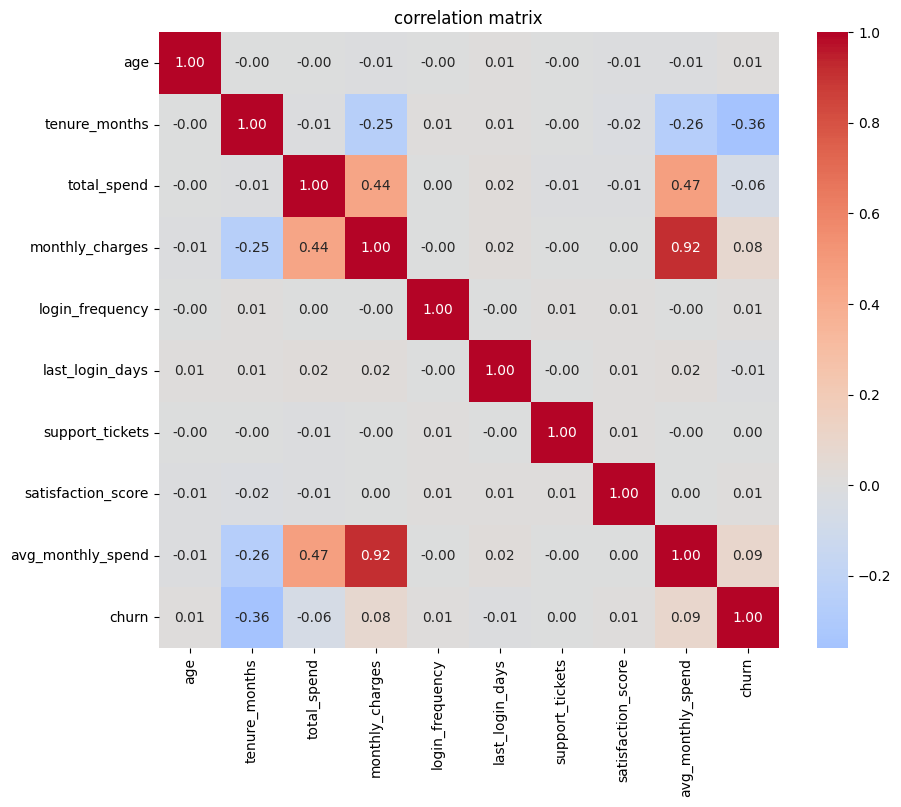

In [25]:
import seaborn as sns
plt.figure(figsize = (10,8))
sns.heatmap(df[num_cols].corr().round(2),
            annot= True,
            cmap='coolwarm',
            center =0,
            fmt = '.2f')
plt.title("correlation matrix")
plt.show()

In [26]:
print(df[['avg_monthly_spend','monthly_charges']].corr())

                   avg_monthly_spend  monthly_charges
avg_monthly_spend           1.000000         0.917073
monthly_charges             0.917073         1.000000


In [27]:
df_encoded = pd.get_dummies(df,
                            columns=['gender','city','contract_type','payment_method','device','referral_source'],
                            drop_first = True)
print(df_encoded.shape)

(15002, 39)


In [28]:
print(df_encoded.head(10))

  customer_id        age  tenure_months  monthly_charges  total_spend  \
0  CUST_00000  55.169189      11.262434        16.672943   399.765794   
1  CUST_00001  35.197928      72.242914        11.999928   866.909782   
2  CUST_00002  25.183974      31.601897        13.976009   441.668402   
3  CUST_00003  35.197928      21.910621         0.751351    16.462563   
4  CUST_00004  28.393592       4.070997        17.630382    71.773229   
5  CUST_00005  27.599239       4.070311        63.337272   257.802396   
6  CUST_00006  40.198209       1.436130        16.672943   187.030303   
7  CUST_00007  18.000000      48.269541         3.536709   170.715313   
8  CUST_00008  18.000000      22.057972         3.763290    83.010544   
9  CUST_00009  35.231491      29.550001         1.764335    52.136095   

   num_products  login_frequency  last_login_days  support_tickets  \
0             4              4.0         9.151080                0   
1             1             10.0        17.503859       

In [29]:
print('gender' in df_encoded.columns)

False


In [31]:
tenure_order= {'<6m':0, '6-12m':1, '1-2yr':2, '2-4yr': 3, '4yr+':4}
df_encoded['tenure_bucket_enc'] = df_encoded['tenure_bucket'].map(tenure_order)
print(df_encoded['tenure_bucket_enc'].value_counts())

tenure_bucket_enc
2    4111
3    3272
0    3241
1    2446
4    1932
Name: count, dtype: int64


In [32]:
df_encoded= df_encoded.drop(columns= ['customer_id', 'tenure_bucket'])
print(df_encoded.shape)

(15002, 38)


In [33]:
import sklearn 
from sklearn.preprocessing import RobustScaler
num_cols_scale = ['age','tenure_months','total_spend',
                  'monthly_charges','login_frequency','last_login_days','support_tickets','satisfaction_score','avg_monthly_spend','support_per_month']
scaler = RobustScaler()
df_encoded[num_cols_scale]=scaler.fit_transform(df_encoded[num_cols_scale])
print(df_encoded[num_cols_scale].describe().round(2))

            age  tenure_months  total_spend  monthly_charges  login_frequency  \
count  15002.00       15002.00     15002.00         15002.00         15002.00   
mean       0.02           0.28         0.50             1.23             0.00   
std        0.73           0.91         1.52             4.82             0.70   
min       -1.17          -0.66        -0.64            -0.41            -2.00   
25%       -0.51          -0.37        -0.33            -0.26            -0.50   
50%        0.00           0.00         0.00             0.00             0.00   
75%        0.49           0.63         0.67             0.74             0.50   
max        3.03           4.17         9.01           122.38             3.75   

       last_login_days  support_tickets  satisfaction_score  \
count         15002.00         15002.00            15002.00   
mean              0.28             0.50               -0.49   
std               0.91             1.23                1.17   
min              -

In [35]:
from sklearn.ensemble import RandomForestClassifier
X= df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

rf = RandomForestClassifier(n_estimators =100, random_state = 42)
rf.fit(X,y)
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(5)
print(importance)

tenure_months        0.124763
total_spend          0.076979
avg_monthly_spend    0.075167
last_login_days      0.072675
monthly_charges      0.070963
dtype: float64
